<center>
    
## <font color='maroon'>ASTR 21100/31200</font>
## <font color='maroon'>Computational techniques in astrophysics<br></font>

## <font color='maroon'>Numerical methods to calculate derivatives<br></font>

</center>

### Instructor: 
Andrey Kravtsov (email: <tt>kravtsov@uchicago.edu</tt>, office: ERC 415)
Professor, Department of Astronomy & Astrophysics


### Teaching Assistants 

Rohan Gupta (rohangupta@uchicago.edu), 
Raul Gomez del Estal Teixeira (raulteixeira@uchicago.edu), 
Avery Metzcar (metzcara@uchicago.edu), 
Megan Zhao (yifanzyf@uchicago.edu)


In [4]:
import numpy as np 

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

from codes.plotting import plot_prettier

plot_prettier()

## <font color='blue'>Computing derivatives numerically

``*Finite differences have, in themselves, but little importance to the student of matter and ether. They are here regarded simply as a makeshift for infinitesimals; and the understanding is always that we will eventually make the differences so small that the errors due to their finite size will be less than the errors of experiment of practical working, and may therefore be disregarded. That it is possible to make them small enough without much labour is illustrated by examples given hereafter.*''
    
                -- Lewis Fry Richardson, 1910
    
    
<p>
<center>
<img size=500 src="http://astro.uchicago.edu/~andrey/classes/a330f17/fig/Lewis_Fry_Richardson_wiki_photo.png"></img>
</center>
<center>Lewis Fry Richardson</center>


For some functions we can derive mathematical expression for a function derivative. For many others, such derivatives are either difficult or impossible to compute using direct mathematical derivation. In such cases it is still possible to compute approximate derivatives numerically. 
    
Also, in practice we often deal with tabulated data. Derivatives of functions represented by such data evaluated only at certain discrete values of their argument also need to be evaluated numerically (i.e., using calculations of the kind discussed below). 

### <font color='darkblue'>An example: duration of day in Chicago throughout the year and rate of its change</font>
 

This example is based on Sections 2.1.1 and 2.1.2 in the <a href="https://link.springer.com/content/pdf/10.1007%2F978-3-030-70347-9.pdf">"Numerical Python in Astronomy and Astrophysics" book</a>. 


Compute declination of the Sun in the <a href="https://en.wikipedia.org/wiki/Right_ascension">Right Ascension (RA) - Declination (Dec) astronomical coordinate system</a> used to describe coordinates of objects on the sky for a given day $N$ since January 1 (January 1st is $N=0$). 

Using NumPy we can compute it for all 365 days using numpy operations. 

In [5]:
import math

def plot_day_duration(lat_deg=41, lat_min=51, lat_sec=11, loc_name='Chicago',
                     figsize=(3,3)):
    """
    Compute duration of a day for the input location latitude
    
    Returns:
        nday - array of ints, from 1 to 365, days of the year 1 is Jan 1
        tday - array of 365 floats, duration of a day by date in hours
        tday_func - spline approximation to tday(nday) that can be used as a 
             function to return tday for any float value between 1 and 365
    """
    # angular velocity in rad/day; 365.24 is the average number of days in a year
    omega = 2*math.pi / 365.24 
    ecl = math.radians(23.44) # obliquity of the ecliptic

    n = np.arange(1, 366, 1) # generate a numpy array of length 365 with values from 0 to 365
    delta_sun = -np.arcsin(np.sin(ecl) * np.cos(omega*(n + 10)))
    # Chicago latitude: 41° 51' 0.11"
    # -> to radians = (degrees + arcminutes/60 + arcseconds/(60*60)) * pi/180 
    # factor pi/180 converts from degrees to radians because pi radians = 180 degrees 
    phi = (lat_deg + lat_min/60 + lat_sec/3600) * np.pi/180
    #print(f'{loc_name} latitude in radians = {phi:.5f}')
    
    # calculate the length of time the Sun is up in hours
    # numpy functions such as np.tan and np.arccos can operate on all elements in the array
    # functions like math.tan can operate only on a single number at a time
    hday = np.arccos(-np.tan(delta_sun) * math.tan(phi))
    day_duration = (np.degrees(2*hday)/360) * 23.934469592
    
    # plot the number of hours the Sun is up in Chicago throughout the year
    plt.figure(figsize=figsize)
    plt.xlabel(r'$N_{\rm day}$ (Jan 1 is $N=0$)')
    plt.ylabel(r'$t_\odot$'+r' in '+f'{loc_name}'+ r' in hours')
    plt.plot(n, day_duration)
    plt.grid(ls='dotted', color='gray')
    plt.show()
    
    from scipy.interpolate import UnivariateSpline
    # constuct smooth spline approximation through the points 
    tdaysp = UnivariateSpline(n, day_duration, s=0.) 

    return n, day_duration, tdaysp

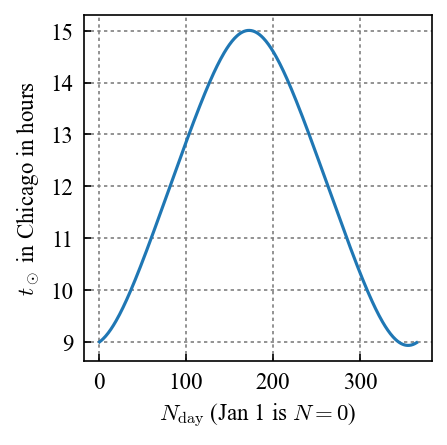

In [6]:
days, tday, day_duration_func = plot_day_duration()

### <font color='blue'>Numerical evaluation of $f^\prime(x)$</font>

1st order estimate of the first derivative: 
    
$$\frac{f(x_0+h) - f(x_0)}{h} \approx f^\prime(x_0)$$
 

2nd order estimate of the first derivative: 
    
$$\frac{f(x_0+h) - f(x_0-h)}{2h} \approx f^\prime(x_0)$$
 


### <font color='blue'>Numerical evaluation of $f^\prime(x)$</font> 

2nd order estimate of the first derivative (see assigned reading): 
    
$$\frac{f(x_0+h) - f(x_0-h)}{2h} = f^\prime(x_0) + e_2\,h^2 + \mathcal{O}(h^4).$$
 


### <font color='blue'>Exercise 1: compute the rate of change of day length throughout the year</font>

* The code above produces two NumPy arrays: days - days of the year (from 1 to 365; 1 is Jan 1) and tday is duration of time when the Sun is up in Chicago each day. 

* Compute and plot the rate of change of day duration in minutes per day as a derivative of tday with respect to length of time in days using the first order and second order schemes of estimating the derivative shown above. 

* Compute and plot the fractional difference between the 1st and 2nd order results for the derivative. 

If it's easier compute it in a loop, but it's possible to do this using NumPy slicing because days and tday are NumPy arrays. 

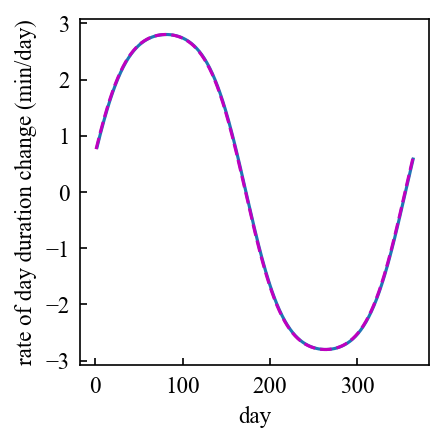

In [8]:
# 1st order derivative estimate
# np.diff computes array of differents of element 1 - element 0, 2-1, 3-2, ...
# this is the same as slicing (tday[1:] - tday[:-1])
der1 = np.diff(tday)
# 2nd order derivative estimate
# this will be defined only for the 2nd to next to last days
# the first and last days will be ignored
der2 = (tday[2:] - tday[:-2]) / 2

plt.figure(figsize=(3,3))
plt.xlabel(r'day')
plt.ylabel(r'rate of day duration change (min/day)')
plt.plot(days[1:-1], der2*60)
plt.plot(days[:-1], der1*60, ls='--', c='m')
plt.show()

The plot shows that both estimates provide sensible results. The maximum rates of change of the daylight duration are around March 21 (day ~80) and September 21, when they reach values just shy of 3min/day. 

The rate of change is close to zero around December 21 and June 21. This is why the days feel the same length and dark around this time of the year. 

The fractional plot below shows that the 1st order derivative estimate becomes quite inaccurate (tens of 10% error) when the rate of change is close to 

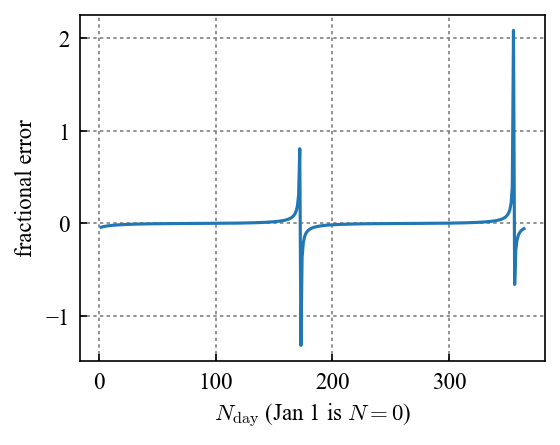

In [9]:
# 2nd order estimate is only defined starting from 2nd element
# 1st order is from the 1st, so this is taken into account in using der1[1:]
frac_err = (der2 - der1[1:]) / der2

plt.figure(figsize=(4,3))
plt.xlabel(r'$N_{\rm day}$ (Jan 1 is $N=0$)')
plt.ylabel(r'fractional error')
plt.grid(ls='dotted', color='gray')
plt.plot(days[1:-1], frac_err)
plt.show()

Absolute error is shown below. It is quite small, which is why the lines of two rate estimates seem to be the same. However, the error is far from zero and when the value of the rate becomes close to 0, the fractional error becomes quite large. 

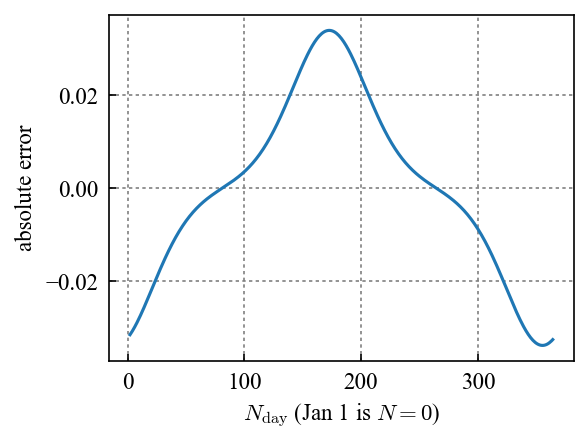

In [11]:
abs_err = (der2 - der1[1:]) * 60 # in min/day

plt.figure(figsize=(4,3))
plt.xlabel(r'$N_{\rm day}$ (Jan 1 is $N=0$)')
plt.ylabel(r'absolute error')
plt.grid(ls='dotted', color='gray')
plt.plot(days[1:-1], abs_err)
plt.show()

### <font color='blue'>Exercise 2: implement the 4th order scheme for derivative using Richardson's trick</font>

* implement two functions that will compute the 2nd and 4th order accurate derivatives using Richardson's trick (see Section 3.3 of the [notes on derivatives](https://astro.uchicago.edu/~andrey/classes/a211w24/html/numdiff/index.html). You can use <tt>day_duration_func</tt> returned by <tt>plot_day_duration</tt> in the code as a function for any input value between 1 and 365, as shown in the example below. 

* Use the implemented functions to compute the rate of change of the day duration as a function of day of the year. 


* Plot the 2nd and 4th order estimates of the derivatives as a function of day of the year (array from 1 to 365, with any reasonable $\Delta t\leq 1$ day you choose. 


* Compute and plot the fractional difference between the 2nd and 4th order estimates of the derivative relative to the 4th order one. 


In [52]:
# Duration of light time of the day on Dec 21 in hours
print(day_duration_func(346.5))

8.971260329259852


In [13]:
def der1_2(func, x, h):
    '''
    2nd order estimate of the first derivative for input function func
    evaluated with the step h
    '''
    return (func(x+h) - func(x-h))/(2*h) 

def der1_4(func, x, dx): 
    '''
    4th order derivative estimate using Richardson's trick
    for the input f(x) with step size dx
    '''
    return (4*der1_2(func, x, dx/2) - der1_2(func, x, dx))/3 

def der1_6(func, x, dx): 
    '''
    6th order derivative estimate using Richardson's trick
    for the input f(x) with step size dx
    '''
    return (16*der1_4(func, x, dx/2) - der1_4(func, x, dx))/15 


In [17]:
# use the same h = 1 day as in exercise 1
step = 1.

# 2nd order estimate
der2 = der1_2(day_duration_func, days, step)
# 4th order estimate
der4 = der1_4(day_duration_func, days, step)
# 6th order estimate
der6 = der1_6(day_duration_func, days, step)

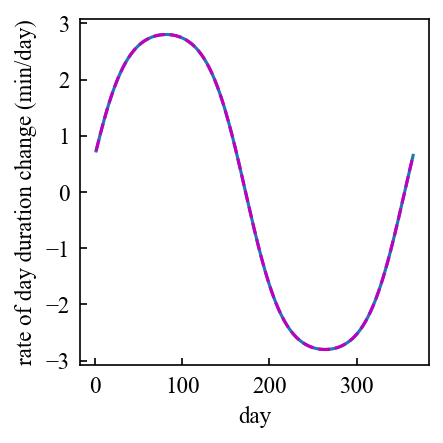

In [19]:
plt.figure(figsize=(3,3))
plt.xlabel(r'day')
plt.ylabel(r'rate of day duration change (min/day)')
plt.plot(nday, der2*60)
plt.plot(nday, der4*60, ls='--', c='m')
plt.show()

The fractional difference of the 2nd and 4th order estimate is much smaller than for the 1st vs 2nd, which shows just how much more accurate the 2nd order is compared to the first order. 

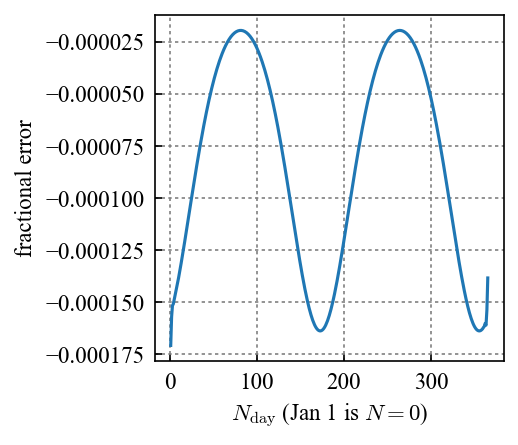

In [16]:
fracerr = (der2 - der4) / der4

plt.figure(figsize=(3,3))
plt.xlabel(r'$N_{\rm day}$ (Jan 1 is $N=0$)')
plt.ylabel(r'fractional error')
plt.plot(nday, fracerr)
plt.grid(ls='dotted', color='gray')
plt.show()

Comparing 4th order to 6th order estimate we see that the difference is even smaller. The fractional error decreases very fast with the increasing order of the scheme. 

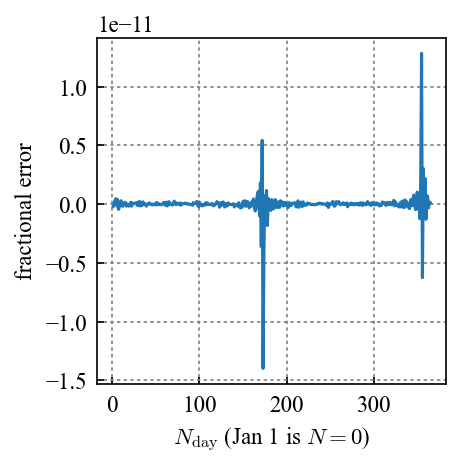

In [20]:
fracerr = (der4 - der6) / der6

plt.figure(figsize=(3,3))
plt.xlabel(r'$N_{\rm day}$ (Jan 1 is $N=0$)')
plt.ylabel(r'fractional error')
plt.plot(nday, fracerr)
plt.grid(ls='dotted', color='gray')
plt.show()

### <font color='darkblue'>Order of the scheme and fractional (relative) error
    
We always compute the fractional error either relative to the true value (if it's known) or relative to the more accurate estimate: 
    
    fractional error = (estimate - more_accurate) / more_accurate
   